In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 50)

df = pd.read_csv('life_eval_ssa_analysis.csv')
print(f"Total rows: {len(df)}")
print(f"Flagged (references_ssa_actuarial=True): {df['references_ssa_actuarial'].sum()}")
print(f"Not flagged: {(~df['references_ssa_actuarial']).sum()}")
df[['Model', 'references_ssa_actuarial', 'matched_keywords']].value_counts().reset_index(name='count')

Total rows: 8261
Flagged (references_ssa_actuarial=True): 6244
Not flagged: 2017


,Model,references_ssa_actuarial,matched_keywords,count
0,Llama-3.1-8B,True,Social Security,728
1,Llama-3.1-70B,True,Social Security,514
2,DeepSeek-R1,True,Social Security; life table,359
3,GPT-4o,True,actuarial; life table,327
4,Claude-Sonnet-4,True,life table,303
...,...,...,...,...
139,Gemini-2.5-Pro,True,SSA; mortality table,1
140,Llama-3.1-70B,True,SSA; Social Security,1
141,Llama-3.1-70B,True,Social Security; actuarial; life table; actuarial table,1
142,Llama-3.1-8B,True,SSA; Social Security,1


In [2]:
df

,Reasoning,Answer,Stated Confidence Answer,Coerce,Content,Question ID,Model,Model Type,Question Set,Score,...,Token Probability Answer,Token Probability A,Token Probability B,Token Probability C,Token Probability D,Token Probability E,gini,combined_name,references_ssa_actuarial,matched_keywords
0,"For an American male at birth (0 years), I need to estimate life expectancy. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, this is a statistical average with significant variation. Many factors affect individual longevity including genetics, lifestyle, socioeconomic status, access to healthcare, and random events. My confidence must be extremely low because predicting an individual's age at death within a 1-year range is nearly impossible given the wide distribution of actual death ages and the lack of specific information about this person's health, habits, or genetics.",77.0,0.01,True,"{\n ""Reasoning"": ""For an American male at birth (0 years), I need to estimate life expectancy. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, this is a statistical average with significant variation. Many factors affect individual longevity including genetics, lifestyle, socioeconomic status, access to healthcare, and random events. My confidence must be extremely low because predicting an individual's age at death within a 1-year range is nearly impossible given the wide distribution of actual death ages and the lack of specific information about this person's health, habits, or genetics."",\n ""Answer"": 77,\n ""Confidence"": 0.01\n}",0,Claude-Sonnet-3.7,Claude,LifeEval,0.049038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0_LifeEval,False,NaN
1,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the life expectancy for American males is approximately 76-77 years. However, there's significant variability due to factors like socioeconomic status, access to healthcare, lifestyle choices, and genetic factors that I don't have information about. The standard deviation for age at death is quite large, and predicting an individual's lifespan within 5 years is extremely difficult without specific health and lifestyle information. My confidence must be low given this uncertainty.",77.0,0.25,True,"{\n ""Reasoning"": ""For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the life expectancy for American males is approximately 76-77 years. However, there's significant variability due to factors like socioeconomic status, access to healthcare, lifestyle choices, and genetic factors that I don't have information about. The standard deviation for age at death is quite large, and predicting an individual's lifespan within 5 years is extremely difficult without specific health and lifestyle information. My confidence must be low given this uncertainty."",\n ""Answer"": 77,\n ""Confidence"": 0.25\n}",1,Claude-Sonnet-3.7,Claude,LifeEval,0.244690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1_LifeEval,False,NaN
2,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, this is just an average with significant variation. Many factors affect longevity including genetics, lifestyle, socioeconomic status, access to healthcare, and random events that I have no information about for this individual. The question asks for confidence within a 10-year range, which means I need to estimate the probability that the actual age at death will be within ±10 years of my prediction. Given the wide variability in human lifespans and the lack of specific information about this person, my confidence must be moderate.",77.0,0.65,True,"{\n ""Reasoning"": ""For an American male at birth (0 years),

## Summary stats: confidence by flag

In [2]:
df.groupby('references_ssa_actuarial')[['Stated Confidence Answer', 'Score', 'Answer']].agg(['mean', 'median', 'std']).round(4)

Stated Confidence Answer                  Score  \
                                             mean median     std    mean   
references_ssa_actuarial                                                   
False                                      0.6707   0.70  0.2032  0.5293   
True                                       0.5848   0.65  0.2640  0.5357   

                                           Answer                 
                          median     std     mean median     std  
references_ssa_actuarial                                          
False                     0.5342  0.3357  83.3128   81.0  6.4314  
True                      0.5446  0.3457  85.3695   84.0  7.0582

## Browse flagged responses
Shows `Reasoning`, `matched_keywords`, `Model`, `Answer`, `Stated Confidence Answer`, and `Score`.

In [3]:
cols = ['Model', 'Question ID', 'Answer', 'Stated Confidence Answer', 'Score', 'matched_keywords', 'Reasoning']

flagged = df[df['references_ssa_actuarial'] == True][cols].reset_index(drop=True)
print(f"{len(flagged)} flagged responses")
flagged

6244 flagged responses


,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning
0,Claude-Sonnet-3.7,16,78.0,0.05,0.051995,actuarial; actuarial table,"For an American male who has already survived to age 4, I need to consider life expectancy statistics. The current life expectancy for American males at birth is approximately 76-77 years. Having survived early childhood (past age 4) slightly increases this expectancy, as infant and early childhood mortality is removed from the calculation. However, predicting an exact age of death is extremely difficult due to numerous factors including genetics, lifestyle, socioeconomic status, access to healthcare, and random events. Life expectancy statistics give averages across populations, not precise predictions for individuals. Additionally, asking for confidence within 1 year of the true value requires extreme precision that demographic statistics cannot provide. Even actuarial tables used by insurance companies provide ranges, not exact ages."
1,Claude-Sonnet-3.7,24,78.0,0.02,0.052014,actuarial; actuarial table,"For an American male who has already reached 6 years of age, I need to consider life expectancy statistics. The current life expectancy for American males at birth is approximately 76-77 years. Having survived to age 6 slightly increases this expectancy, as infant and early childhood mortality is no longer a factor. However, predicting an exact age of death is extremely difficult due to numerous variables including genetics, lifestyle, socioeconomic factors, future medical advances, and random events. Being asked to predict within 1 year of the true value makes this an extremely low confidence prediction, as even actuarial tables work with ranges of many years."
2,Claude-Sonnet-3.7,28,78.0,0.02,0.052021,actuarial; actuarial table,"For an American male who has already reached 7 years of age, I need to consider life expectancy statistics. The current life expectancy for American males at birth is approximately 76-77 years. Having survived to age 7 slightly increases this expectancy, as infant and early childhood mortality is no longer a factor. However, predicting an exact age of death is extremely difficult due to numerous variables including genetics, lifestyle, socioeconomic factors, future medical advances, and random events. Being asked to predict within 1 year of the true value makes this an extremely low confidence prediction, as even actuarial tables work with ranges of many years."
3,Claude-Sonnet-3.7,48,78.0,0.05,0.052054,actuarial; actuarial table,"For an American male who has already reached 12 years of age, I need to consider life expectancy statistics. The current life expectancy for American males at birth is approximately 76-77 years. Since this person has already survived to age 12, their life expectancy would be slightly higher than the at-birth expectancy due to having already survived childhood risks. However, there's enormous variability in individual lifespans due to genetics, lifestyle, socioeconomic factors, access to healthcare, and random events. Being within 1 year of the true value requires extreme precision that population statistics cannot provide. Even actuarial tables give ranges, not precise ages of death."
4,Claude-Sonnet-3.7,60,77.0,0.05,0.049481,actuarial; actuarial table,"For an American male who has already reached 15 years of age, I need to consider life expectancy statistics. The current life expectancy for American males at birth is approximately 76-77 years. However, since this person has already survived to age 15, their life expectancy is slightly higher than at birth because they've already survived early childhood mortality risks. Based on actuarial tables, a 15-year-old American male would have a life expectancy of roughly 76-78 years. However, predicting an exact age of death is extremely difficult due to numerous factors including genetics, lifestyle, socioeconomic status, access to healthcare, and random events. Being confiden

In [5]:
print(flagged.Reasoning[1].replace('. ', '.\n'))

For an American male who has already reached 6 years of age, I need to consider life expectancy statistics.
The current life expectancy for American males at birth is approximately 76-77 years.
Having survived to age 6 slightly increases this expectancy, as infant and early childhood mortality is no longer a factor.
However, predicting an exact age of death is extremely difficult due to numerous variables including genetics, lifestyle, socioeconomic factors, future medical advances, and random events.
Being asked to predict within 1 year of the true value makes this an extremely low confidence prediction, as even actuarial tables work with ranges of many years.


## Browse unflagged responses (sample)

In [7]:
# Adjust n to see more/fewer unflagged examples
n = 20

unflagged = df[df['references_ssa_actuarial'] == False][cols].reset_index(drop=True)
print(f"{len(unflagged)} unflagged responses (showing {min(n, len(unflagged))})")
unflagged.head(n)

2017 unflagged responses (showing 20)


,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning
0,Claude-Sonnet-3.7,0,77.0,0.01,0.049038,NaN,"For an American male at birth (0 years), I need to estimate life expectancy. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, this is a statistical average with significant variation. Many factors affect individual longevity including genetics, lifestyle, socioeconomic status, access to healthcare, and random events. My confidence must be extremely low because predicting an individual's age at death within a 1-year range is nearly impossible given the wide distribution of actual death ages and the lack of specific information about this person's health, habits, or genetics."
1,Claude-Sonnet-3.7,1,77.0,0.25,0.244690,NaN,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the life expectancy for American males is approximately 76-77 years. However, there's significant variability due to factors like socioeconomic status, access to healthcare, lifestyle choices, and genetic factors that I don't have information about. The standard deviation for age at death is quite large, and predicting an individual's lifespan within 5 years is extremely difficult without specific health and lifestyle information. My confidence must be low given this uncertainty."
2,Claude-Sonnet-3.7,2,77.0,0.65,0.487341,NaN,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, this is just an average with significant variation. Many factors affect longevity including genetics, lifestyle, socioeconomic status, access to healthcare, and random events that I have no information about for this individual. The question asks for confidence within a 10-year range, which means I need to estimate the probability that the actual age at death will be within ±10 years of my prediction. Given the wide variability in human lifespans and the lack of specific information about this person, my confidence must be moderate."
3,Claude-Sonnet-3.7,3,77.0,0.68,0.834496,NaN,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, there's significant variability due to factors like socioeconomic status, access to healthcare, lifestyle choices, and genetics - none of which I know for this individual. The standard deviation for male lifespans is roughly 15 years. Being asked for confidence within a 20-year range gives me a relatively wide window, which increases confidence, but predicting an individual's lifespan from just gender and nationality still involves substantial uncertainty."
4,Claude-Sonnet-3.7,4,77.0,0.05,0.049337,NaN,"For an American male who has already lived to at least 1 year, I need to consider life expectancy statistics. The current life expectancy for American males at birth is approximately 76-77 years. Having survived infancy (which has slightly higher mortality risk) would marginally increase this expectation. However, predicting an exact age of death is extremely difficult due to numerous factors including genetics, lifestyle, socioeconomic status, access to healthcare, and random events. Life expectancy is a statistical average with significant variance. Being within 1 year of the true value requires extraordinary precision that demographic statistics alone cannot provide. My confidence must be very low given this uncertainty."
5,Claude-Sonnet-3.7,5,78.0,0.60,0.258134,NaN,"For an American male who has already lived to at least 1 year, I need to consider life expectancy statistics. The current life expectancy for American males at birth is approximately 76-77 years. Having survived infancy (past 1 year) 

## Side-by-side: same Question ID, flagged vs. unflagged

In [6]:
flagged_qids = set(df[df['references_ssa_actuarial'] == True]['Question ID'])
unflagged_qids = set(df[df['references_ssa_actuarial'] == False]['Question ID'])
overlap_qids = sorted(flagged_qids & unflagged_qids)
print(f"{len(overlap_qids)} question IDs with both flagged and unflagged responses")

# Show first few overlapping questions
show_qids = overlap_qids[:5]

for qid in show_qids:
    subset = df[df['Question ID'] == qid][cols + ['references_ssa_actuarial']].sort_values('references_ssa_actuarial', ascending=False)
    print(f"\n{'='*80}")
    print(f"Question ID: {qid}")
    display(subset.reset_index(drop=True))

742 question IDs with both flagged and unflagged responses

Question ID: 0


,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning,references_ssa_actuarial
0,DeepSeek-R1,0,76.0,0.034,0.046215,Social Security; life table,"The average life expectancy for an American male at birth is approximately 76 years based on pre-pandemic data (e.g., CDC and WHO sources), though recent declines (e.g., to 73–74 years post-COVID) add uncertainty. Lifespan variability is high—standard deviation is ~15 years—so individual outcomes diverge significantly from the mean. Using the Social Security Administration’s 2019 period life table, the probability of dying within 1 year of 76 (i.e., ages 75–77) is only 3.4% for newborns. This low probability reflects broad dispersion in lifespans and sensitivity to health, socioeconomic, and temporal factors. Confidence is further reduced by using outdated data and the precision demand (±1 year).",True
1,Gemini-2.5-Pro,0,74.0,0.075,0.041153,life table,"The estimate is based on the most recent life expectancy at birth for males in the United States, which, according to the CDC's 2022 data, is approximately 73.5 years. This figure represents the average age of death for a male born today. However, predicting the exact age of death for any single individual is highly uncertain due to wide variation in genetics, lifestyle, and random events. The confidence reflects this uncertainty; it is the statistical probability that a random American male will die within a 3-year window (+/- 1 year) centered on the average life expectancy, calculated using national life tables. This probability is inherently low because deaths are distributed across a wide range of ages, and very few individuals die at the exact average age.",True
2,GPT-o3,0,74.0,0.250,0.041153,SSA,"The best benchmark for how long a newborn American male is expected to live is the period life-expectancy at birth published each year by the National Center for Health Statistics. The most recent finalized (2021) figure is 73.2 years, while provisional 2022 numbers and other sources (e.g., SSA) place it around 73.5–74 years. Using these data, the central estimate is roughly 74 years. Because the number shifts by a few tenths of a year from one release to the next and depends on whether one uses period or cohort tables, the chance that my point estimate is within ±1 year (i.e., between 73 and 75) is modest but far from certain.",True
3,Llama-3.1-70B,0,76.0,0.050,0.046215,Social Security,"According to the Social Security Administration, the average life expectancy for an American male is around 76 years. However, since the person has already lived at least 0 years, we can assume that they have survived the high infant mortality rates and other early-life risks. Therefore, we can use the average life expectancy as a rough estimate. However, there is a wide range of individual variation, and many factors can influence an individual's lifespan, such as lifestyle, genetics, and access to healthcare. Given that we have no additional information about the person, we will use the average life expectancy as our best guess.",True
4,Llama-3.1-8B,0,76.0,0.700,0.046215,Social Security,"According to the Social Security Administration, the average life expectancy for an American male at birth is approximately 76.2 years. However, this number can vary depending on various factors such as lifestyle, genetics, and health conditions. Since the person has already lived at least 0 years, we can assume they have survived the most critical early years of life. Therefore, we can use the average life expectancy as a rough estimate. However, considering the person has already lived at least 0 years, we should add a small buffer to account for the fact that they have already overcome some of the most significant mortality risks.",True
5,Claude-Sonnet-3.7,0,77.0,0.010,0.049038,NaN,"For an American male at birth (0 years), I need to estimate life expectancy. According to recent data, the average life expectancy for American males is appro


Question ID: 1


,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning,references_ssa_actuarial
0,Gemini-2.5-Pro,1,73.0,0.20,0.199396,mortality table,"The question asks for a life expectancy estimate for a US male at birth. Based on the most recent final data from the US Centers for Disease Control and Prevention (CDC) National Center for Health Statistics (2021), the life expectancy for a male at birth is 73.2 years. I will use 73 as the integer estimate. This number represents the average age at death for a large population cohort, not a precise prediction for an individual. The actual age of death for any single person is subject to immense variability due to genetics, lifestyle, socioeconomic factors, and random events like accidents. Predicting a single individual's lifespan is therefore highly uncertain. My confidence score reflects the probability that a random individual from this cohort will die within a 10-year window (from age 68 to 78) centered on this average. Based on mortality tables, only about 20% of males die within this specific age range, making my confidence in being correct for any given individual quite low.",True
1,GPT-o3,1,75.0,0.28,0.221231,life table,"For a newborn U.S. male, the most recent CDC life-table data (2021) place life expectancy at birth at roughly 74–75 years. Historical trends show small annual improvements, but offsetting factors (obesity, opioids, COVID shocks) have flattened or slightly lowered the curve. Using 75 as the central estimate, rounding to the nearest whole year gives 75. The spread of individual lifetimes is large: a rough standard deviation is about 15 years. A ±5-year window around 75 therefore covers about one-third of the distribution (~26–30 %). Allowing for uncertainty in the underlying life table, I give myself about a 0.28 chance of being within 5 years of the true age for a randomly selected individual.",True
2,Llama-3.1-70B,1,76.0,0.60,0.232835,Social Security,"According to the Social Security Administration, the average life expectancy for an American male is around 76 years. Since the person has already lived at least 0 years, I will use this average as a starting point. However, I must consider that this is a very broad estimate and there is a wide range of possible ages. Given the lack of any additional information, I will assume a normal distribution around the average life expectancy.",True
3,Llama-3.1-8B,1,76.0,0.70,0.232835,Social Security,"According to the Social Security Administration, the average life expectancy for an American male at birth is approximately 76.2 years. However, this number can vary depending on various factors such as lifestyle, genetics, and health conditions. Considering the person has already lived at least 0 years, we can assume they have survived the most critical early childhood mortality risks. Therefore, we can use the average life expectancy as a rough estimate for their remaining lifespan.",True
4,Claude-Sonnet-3.7,1,77.0,0.25,0.244690,NaN,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the life expectancy for American males is approximately 76-77 years. However, there's significant variability due to factors like socioeconomic status, access to healthcare, lifestyle choices, and genetic factors that I don't have information about. The standard deviation for age at death is quite large, and predicting an individual's lifespan within 5 years is extremely difficult without specific health and lifestyle information. My confidence must be low given this uncertainty.",False
5,Claude Haiku 3,1,83.0,0.80,0.305038,NaN,"Based on population statistics, the average life expectancy for an American male is around 76 years. However, since the person has already lived at least 0 years, we can assume they have already survived the highest risk period of childhood and infancy. Therefore, their remaining life expectancy is likely higher than the general p


Question ID: 2


,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning,references_ssa_actuarial
0,DeepSeek-R1,2,76.0,0.604,0.469277,Social Security; life table,"The average life expectancy for U.S. males is approximately 76 years, based on recent CDC data. However, individual lifespans vary significantly due to factors like genetics, lifestyle, and healthcare access. Using the U.S. Social Security Administration's 2019 period life table for males, 60.4% of newborn males die between ages 66 and 86—within 10 years of the 76-year estimate. This accounts for variability but remains uncertain due to unknown future risks (e.g., pandemics, accidents). Confidence is moderate but not high, as 39.6% fall outside this range.",True
1,Gemini-2.5-Pro,2,74.0,0.420,0.431631,Social Security; life table,"The question is about the life expectancy of an American male from birth. According to the most recent data from the U.S. Centers for Disease Control and Prevention (CDC), the average life expectancy for a male born in the United States is approximately 73.5 years. This figure represents the mean of a wide distribution of ages at death. The confidence score reflects the probability that a random American male's actual age at death will fall within a 20-year window (my answer of 74 ± 10 years, i.e., between 64 and 84). Based on U.S. Social Security life tables, approximately 42% of males die within this age range. A significant number die younger due to accidents and disease, and many live longer, which means my confidence that any specific individual will fall into this range is less than 50%.",True
2,Llama-3.1-70B,2,76.0,0.680,0.469277,Social Security,"According to the Social Security Administration, the average life expectancy for an American male is around 76 years. Since the person has already lived at least 0 years, I will use this average as a starting point. However, I must consider that this is a very broad estimate and there is a wide range of possible outcomes. Given the lack of any additional information, I will assume a normal distribution around the mean.",True
3,Llama-3.1-8B,2,76.0,0.700,0.469277,Social Security,"According to the Social Security Administration, the average life expectancy for an American male at birth is approximately 76.2 years. However, this number can vary depending on various factors such as lifestyle, genetics, and health conditions. Considering the person has already lived at least 0 years, we can assume they have survived the most critical early childhood mortality risks. Therefore, we can use the average life expectancy as a rough estimate for their remaining lifespan.",True
4,Claude-Sonnet-3.7,2,77.0,0.650,0.487341,NaN,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, this is just an average with significant variation. Many factors affect longevity including genetics, lifestyle, socioeconomic status, access to healthcare, and random events that I have no information about for this individual. The question asks for confidence within a 10-year range, which means I need to estimate the probability that the actual age at death will be within ±10 years of my prediction. Given the wide variability in human lifespans and the lack of specific information about this person, my confidence must be moderate.",False
5,Claude Haiku 3,2,83.0,0.800,0.555700,NaN,"Based on population statistics for American males, the average life expectancy is around 76 years. However, since the person has already lived at least 0 years, their remaining life expectancy is likely higher than the general population average. Assuming the person is in reasonably good health, a reasonable estimate would be that they live to around 80-85 years old. I am fairly confident in this estimate, as it takes into account the person's current age while still aligning with typical life 


Question ID: 3


,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning,references_ssa_actuarial
0,Gemini-2.5-Pro,3,74.0,0.83,0.814209,Social Security; actuarial; life table,"The estimate is based on the average life expectancy for a male in the United States at birth, which according to the CDC's 2021 data is approximately 73.5 years. I will round this up to 74. However, life expectancy is an average, and individual lifespans vary significantly due to genetics, lifestyle, and chance events. The confidence level is calculated based on the probability that a random American male's age at death will fall within a 40-year window centered on this average (74 +/- 20 years, or ages 54 to 94). Using US Social Security Administration actuarial life tables, the vast majority of deaths occur within this wide range, excluding most early-life mortality and those who live to extreme old age. The probability of dying within this range is statistically high, but far from certain.",True
1,Llama-3.1-70B,3,76.0,0.80,0.831361,Social Security,"According to the Social Security Administration, the average life expectancy for an American male is around 76 years. Since the person has already lived at least 0 years, I will use this average as a starting point. However, I must consider that this is just an average and actual lifespans can vary significantly. Given the lack of any additional information about the person's health, lifestyle, or genetics, I will assume a relatively normal distribution around the average.",True
2,Llama-3.1-8B,3,76.0,0.70,0.831361,Social Security,"According to the Social Security Administration, the average life expectancy for an American male at birth is approximately 76.2 years. However, this number can vary depending on various factors such as lifestyle, genetics, and health conditions. Considering the person has already lived at least 0 years, we can assume they have survived the most critical early childhood mortality risks. Therefore, we can use the average life expectancy as a rough estimate for their remaining lifespan.",True
3,Claude-Sonnet-3.7,3,77.0,0.68,0.834496,NaN,"For an American male at birth (0 years), I need to consider current life expectancy statistics. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, there's significant variability due to factors like socioeconomic status, access to healthcare, lifestyle choices, and genetics - none of which I know for this individual. The standard deviation for male lifespans is roughly 15 years. Being asked for confidence within a 20-year range gives me a relatively wide window, which increases confidence, but predicting an individual's lifespan from just gender and nationality still involves substantial uncertainty.",False
4,Claude Haiku 3,3,76.0,0.70,0.831361,NaN,"Based on population statistics for American males, the average life expectancy is around 76 years. However, this is just an average and individual life expectancies can vary significantly depending on various factors such as health, lifestyle, and socioeconomic status. Since the person has already lived at least 0 years, they have already surpassed the infant mortality stage, which is the most vulnerable period. Assuming they have no major health issues, it is reasonable to estimate that they will live to around the average life expectancy for American males, with some potential variation. Given the uncertainty involved, I am moderately confident that my estimate is within 20 years of the true value.",False
5,Claude-Sonnet-4,3,76.0,0.85,0.831361,NaN,"For an American male at birth (age 0), I need to consider current life expectancy statistics. According to recent CDC data, life expectancy for American males is approximately 76-77 years. However, this is an average that includes infant mortality and deaths at all ages. Since the question asks about someone who has 'lived at least 0 years' (essentially at birth), the standard life expe


Question ID: 4


,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning,references_ssa_actuarial
0,DeepSeek-R1,4,77.0,0.09,0.049337,Social Security; life table,"The average life expectancy for a 1-year-old American male is approximately 77 years, based on U.S. life tables accounting for reduced infant mortality risk. However, individual lifespan variability is high (standard deviation ~15 years), and the probability of dying within a narrow 3-year window (76-78) is low. Using Social Security Administration life table data, the combined probability of death at ages 76, 77, or 78 is roughly 9-10% for a current 1-year-old. Confidence is further reduced by uncertainties in future healthcare/societal changes.",True
1,Gemini-2.5-Flash,4,76.0,0.08,0.046497,Social Security; life table,"The average life expectancy for an American male is influenced by infant mortality. Once a male has lived at least 1 year, the very high infant mortality risk has been overcome, slightly increasing his expected total lifespan compared to life expectancy at birth. Based on recent U.S. Social Security Administration and CDC data (e.g., 2020-2022 period life tables), the life expectancy for a male at age 1 is approximately 74.7 to 75.7 additional years. Adding the current age of 1 year, this results in an expected total lifespan of around 75.7 to 76.7 years. Therefore, 76 is a reasonable integer estimate. However, it's crucial to understand that life expectancy is an average. The actual age of death for any given individual is subject to wide variation due to genetics, lifestyle, environment, and random events. The distribution of death ages is broad, meaning a significant percentage of people will die many years before or after the average.",True
2,Gemini-2.5-Pro,4,74.0,0.07,0.041404,mortality table,"The estimate is based on U.S. population statistics. According to the most recent CDC data (2021), the life expectancy for a 1-year-old male is an additional 73.1 years. This leads to a total expected lifespan of 74.1 years, which I have rounded to the integer 74. This figure represents a population average and does not account for individual factors like genetics, health, and lifestyle. The confidence level is low because predicting the lifespan of a single individual is subject to immense variability. While 74 is the statistical average, the actual age of death is a wide distribution. The confidence score reflects the low probability that a single person's age at death will fall within the specific 3-year window of 73-75 years old, based on mortality tables.",True
3,GPT-4o,4,77.0,0.60,0.049337,life table,"The life expectancy for an American male at birth is approximately 76 years. However, since the individual has already lived to be at least 1 year old, his life expectancy increases slightly. Based on life tables, the life expectancy for a 1-year-old American male is slightly higher than at birth, but not significantly so. Therefore, a reasonable estimate for his age at death would be around 76 to 77 years. Given the variability in individual lifespans and the many factors that can influence longevity, there is some uncertainty in this estimate.",True
4,GPT-o3,4,76.0,0.02,0.046497,actuarial,"Using recent U.S. actuarial life-tables, a male who has already reached age 1 can expect to live roughly another 74–75 years. That places his mean age at death around 75–76. Individual lifespans, however, are highly variable (standard deviation ≈ 15 years), so the probability of guessing the exact age within ±1 year is very small.",True
5,Llama-3.1-70B,4,80.0,0.60,0.056935,Social Security,"According to the Social Security Administration, the average life expectancy for an American male is around 76 years. However, since the person has already lived for 1 year, we can assume that he has survived the high infant mortality rate and is likely to live longer than the average. Additionally, advances in medicine and improvements in living standards suggest that he

## Look up a specific Question ID

In [7]:
# Change this to any Question ID you want to inspect
query_qid = overlap_qids[0] if overlap_qids else df['Question ID'].iloc[0]

df[df['Question ID'] == query_qid][cols + ['references_ssa_actuarial']].reset_index(drop=True)

,Model,Question ID,Answer,Stated Confidence Answer,Score,matched_keywords,Reasoning,references_ssa_actuarial
0,Claude-Sonnet-3.7,0,77.0,0.010,0.049038,NaN,"For an American male at birth (0 years), I need to estimate life expectancy. According to recent data, the average life expectancy for American males is approximately 76-77 years. However, this is a statistical average with significant variation. Many factors affect individual longevity including genetics, lifestyle, socioeconomic status, access to healthcare, and random events. My confidence must be extremely low because predicting an individual's age at death within a 1-year range is nearly impossible given the wide distribution of actual death ages and the lack of specific information about this person's health, habits, or genetics.",False
1,Claude Haiku 3,0,76.0,0.700,0.046215,NaN,"Based on population statistics for American males, the average life expectancy is around 76 years. However, this is just a statistical average and individual lifespans can vary significantly. Without any additional information about the person's health, lifestyle, or other factors, the best estimate would be to use the general life expectancy as a starting point. Given that the person has already lived at least 0 years, I would estimate they will live to around 76 years old. I am reasonably confident in this estimate, but there is still a fair amount of uncertainty, so I would assign a confidence level of around 0.7.",False
2,Claude-Sonnet-4,0,76.0,0.050,0.046215,NaN,"For an American male at birth (age 0), I need to consider current life expectancy statistics. According to recent CDC data, life expectancy for American males is approximately 76-77 years. However, predicting an exact age of death for any individual has enormous uncertainty due to countless variables including genetics, lifestyle, accidents, disease, socioeconomic factors, and medical advances. Even population-level statistics have standard deviations of several years. Asking for certainty within 1 year of the true value for a specific individual is extremely difficult - this would require knowing the exact age at death, which is essentially impossible to predict accurately for any given person.",False
3,DeepSeek-R1,0,76.0,0.034,0.046215,Social Security; life table,"The average life expectancy for an American male at birth is approximately 76 years based on pre-pandemic data (e.g., CDC and WHO sources), though recent declines (e.g., to 73–74 years post-COVID) add uncertainty. Lifespan variability is high—standard deviation is ~15 years—so individual outcomes diverge significantly from the mean. Using the Social Security Administration’s 2019 period life table, the probability of dying within 1 year of 76 (i.e., ages 75–77) is only 3.4% for newborns. This low probability reflects broad dispersion in lifespans and sensitivity to health, socioeconomic, and temporal factors. Confidence is further reduced by using outdated data and the precision demand (±1 year).",True
4,DeepSeek-V3,0,76.0,0.100,0.046215,NaN,"The average life expectancy for an American male is approximately 76 years, according to recent statistics. However, this is a broad estimate and individual lifespans can vary significantly based on factors like genetics, lifestyle, and access to healthcare. Without additional specific information about the individual, the best estimate is the population average. The confidence in this estimate being within 1 year of the true value is low, as life expectancy is a statistical average with a wide range of possible outcomes.",False
5,Gemini-2.5-Flash,0,75.0,0.070,0.043471,NaN,"The most appropriate estimate for an individual's lifespan, given no other information beyond being an American male from birth, is to use the average life expectancy for that demographic. As of recent data (e.g., 2022), the life expectancy for males in the United States is approximately 74.8 years. Rounding this to the nearest integer gives 75 years. However

## Keyword breakdown

In [8]:
from collections import Counter

all_keywords = df['matched_keywords'].dropna()
# keywords are semicolon-separated
kw_list = [kw.strip() for cell in all_keywords for kw in str(cell).split(';') if kw.strip()]
kw_counts = pd.Series(Counter(kw_list)).sort_values(ascending=False)
kw_counts.rename('count').to_frame()

,count
Social Security,3842
life table,3388
actuarial,2741
actuarial table,946
SSA,466
mortality table,59
SSA table,6


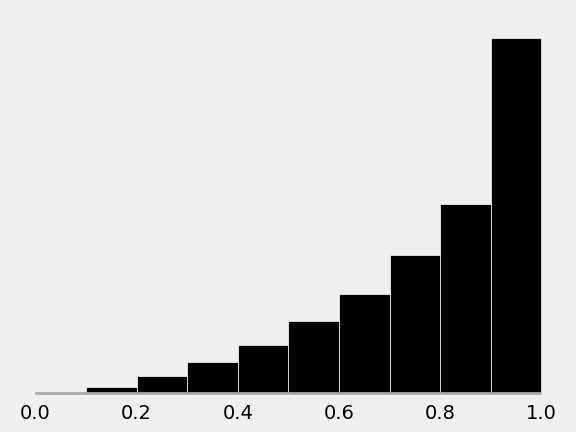

In [9]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

p_values = np.array([])
for i in range(10000):
    data = stats.norm.rvs(size=100)
    p = stats.kstest(data, stats.norm.cdf, args=(np.mean(data), np.std(data))).pvalue
    p_values = np.append(p_values, p)

plt.ylim(-0.05, 4)
plt.hist(p_values, bins=np.arange(0, 1.1, 0.1), color='black', edgecolor='w', density=True)
plt.plot([0, 1], [0, 0], color='darkgrey', lw=2)
plt.grid(False)
plt.yticks([]);

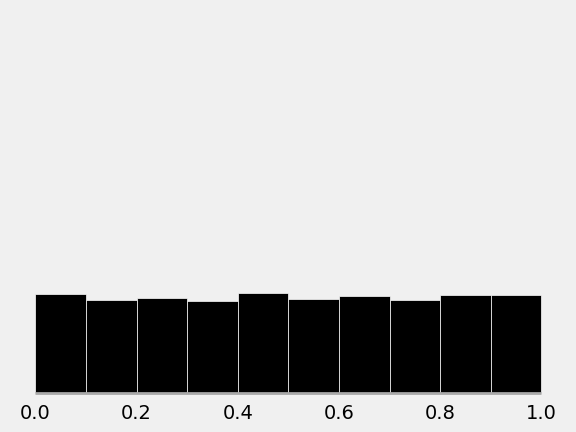

In [10]:
p_values = np.array([])
for i in range(10000):
    data = stats.norm.rvs(size=100)
    p = stats.kstest(data, stats.norm.cdf).pvalue
    p_values = np.append(p_values, p)

plt.ylim(-0.05, 4)
plt.hist(p_values, bins=np.arange(0, 1.1, 0.1), color='black', edgecolor='w', density=True)
plt.plot([0, 1], [0, 0], color='darkgrey', lw=2)
plt.grid(False)
plt.yticks([]);